In [3]:
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
%matplotlib inline
url= "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Tips/tips.csv"
L_df = pd.read_csv(url)


In [6]:
L_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  244 non-null    int64  
 1   total_bill  244 non-null    float64
 2   tip         244 non-null    float64
 3   sex         244 non-null    str    
 4   smoker      244 non-null    str    
 5   day         244 non-null    str    
 6   time        244 non-null    str    
 7   size        244 non-null    int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 15.4 KB


In [7]:
L_df.head()

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


#### 1: distribution plot ??


show the spread and shape of a numerical dataset-> highlighting central tendency , skewness and outliers

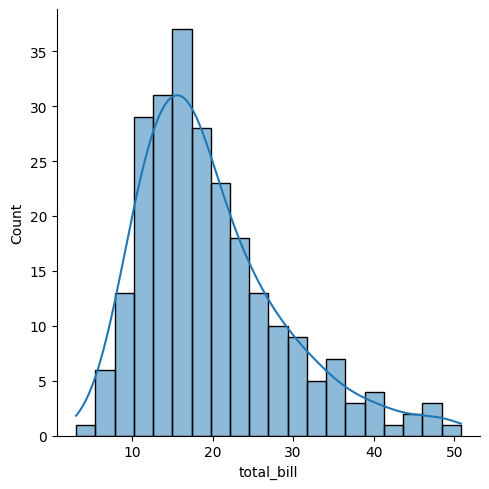

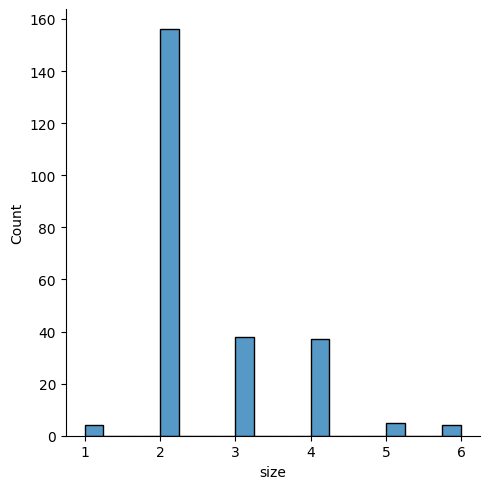

In [14]:
sns.displot(L_df['total_bill'], kde=True, bins=20)
sns.displot(L_df['size'], kde=False, bins=20)


#### Joint plot ??  
shows the relationship between two variables along with their individual distributions


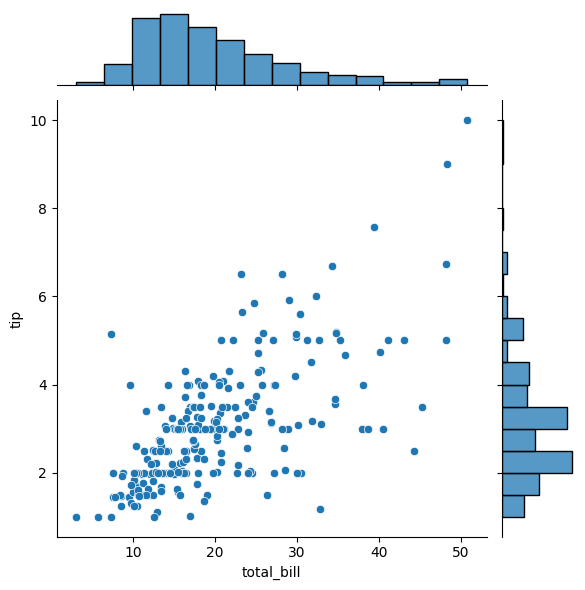

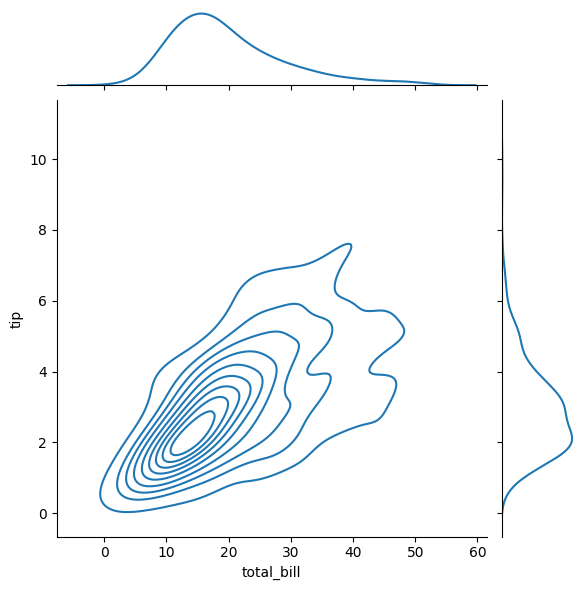

In [ ]:
sns.jointplot(x='total_bill', y='tip', data=L_df , kind='scatter')
sns.jointplot(x='total_bill', y='tip', data=L_df , kind='kde')

#### pair plot ??  
visualizes relationships between multiple numerical variables



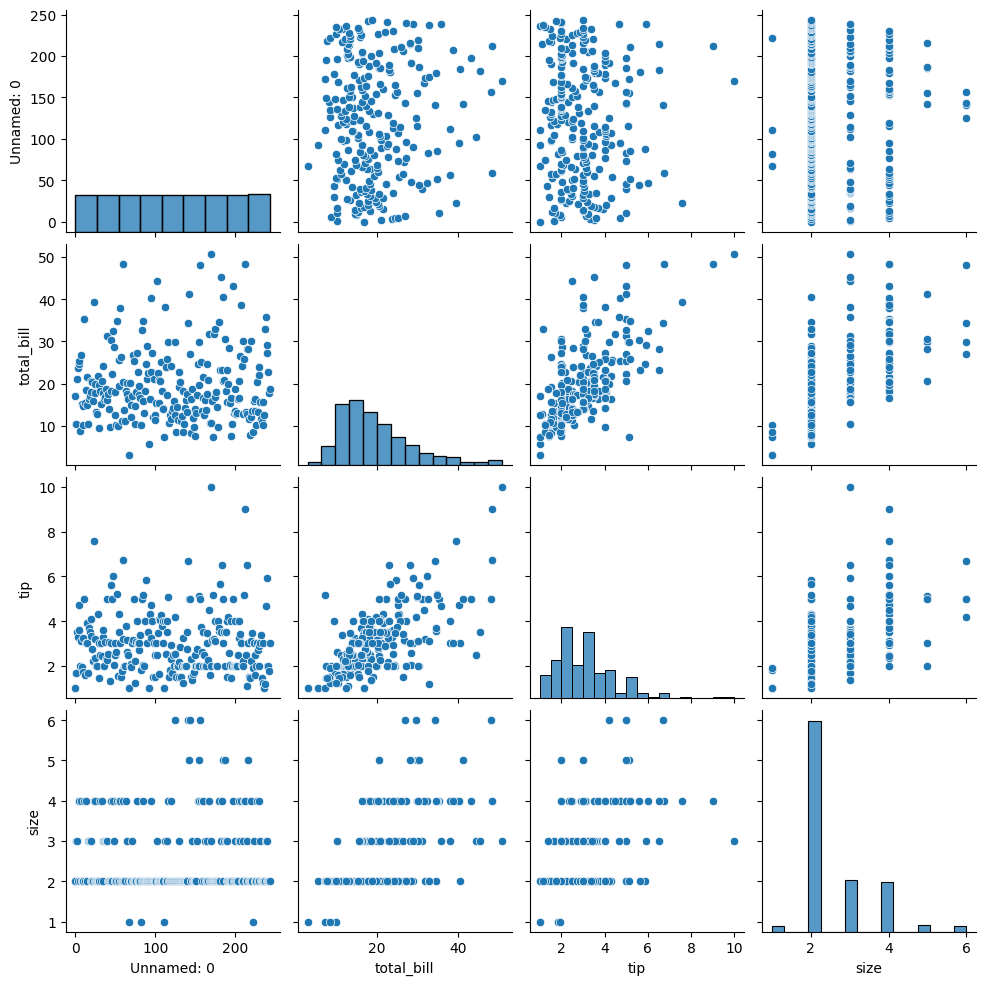

In [18]:
sns.pairplot(L_df)

#### rug plot ??  
shows individual data points as small ticks along an axis to reveal data distribution

<Axes: xlabel='total_bill'>

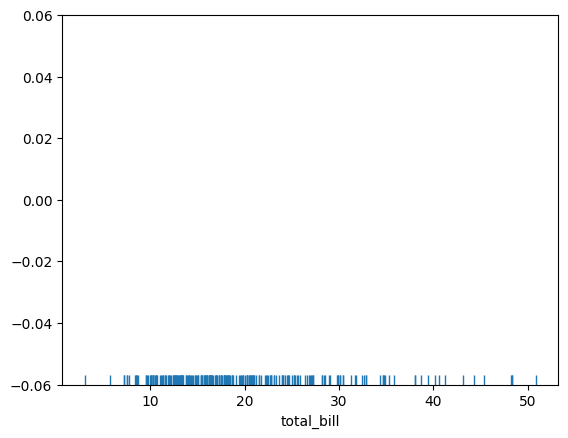

In [20]:
sns.rugplot(L_df['total_bill'])


#### styling  

<Axes: xlabel='total_bill', ylabel='Density'>

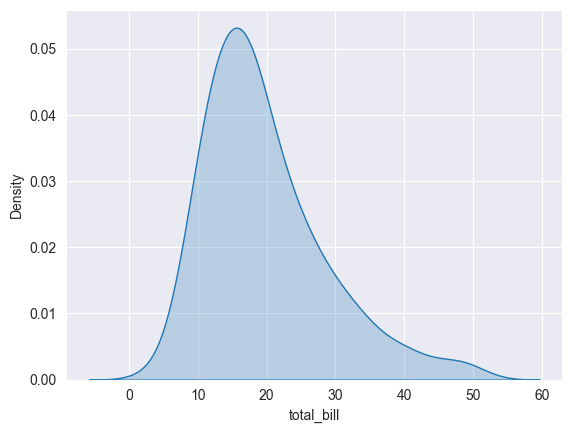

In [23]:
sns.set_style('darkgrid')
sns.kdeplot(L_df['total_bill'], fill=True)

### Categorical plots ?
Instead of focusing on how individual data points are distributed  
they help answer questions like how does one category differ from another?

<Axes: xlabel='day', ylabel='total_bill'>

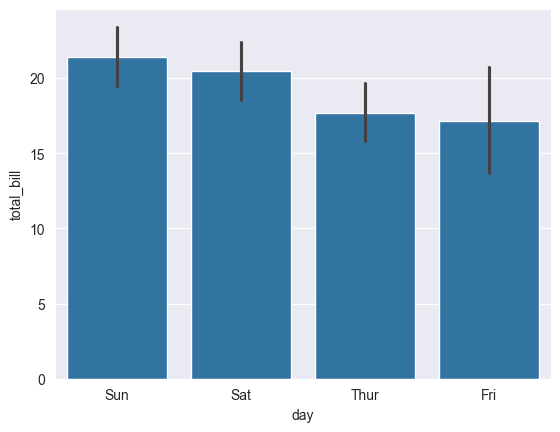

In [ ]:
# bar plot 
sns.barplot(x='day', y='total_bill', data=L_df)


<Axes: xlabel='day', ylabel='count'>

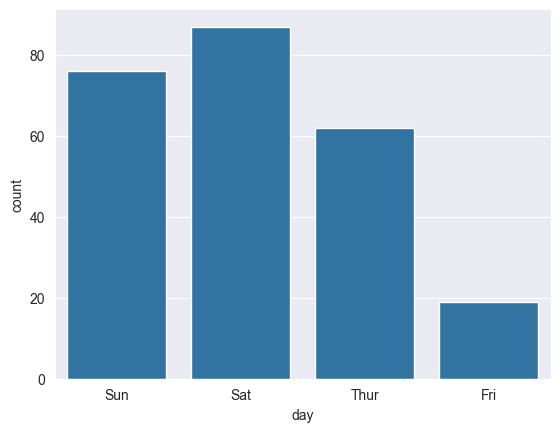

In [25]:
#count plot
sns.countplot(x='day', data=L_df)

<Axes: xlabel='day', ylabel='total_bill'>

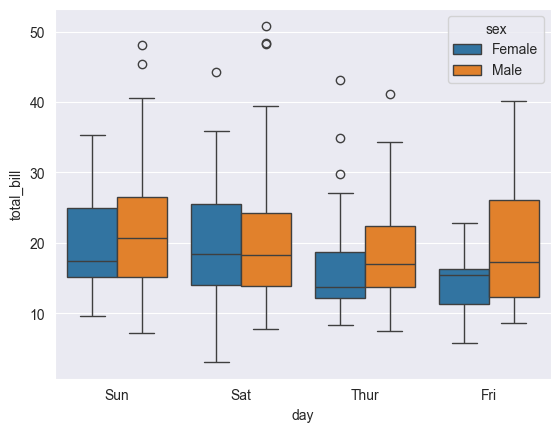

In [28]:
#box plot 
sns.boxplot(x='day', y='total_bill', data=L_df ,  hue='sex')

<Axes: xlabel='day', ylabel='total_bill'>

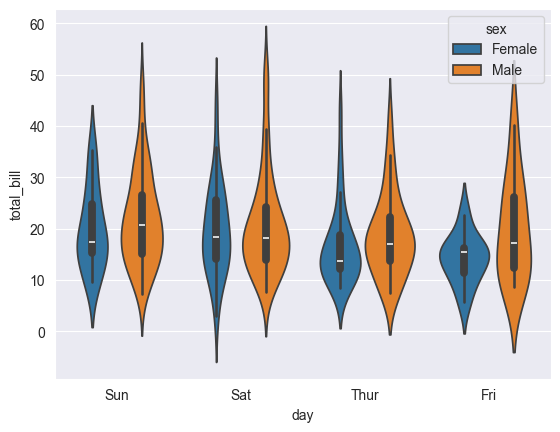

In [29]:
#violin plot
sns.violinplot(x='day', y='total_bill', data=L_df, hue='sex')

### Matrix Plots ?  
visualize relationships between multiple variables using a grid format

<Axes: >

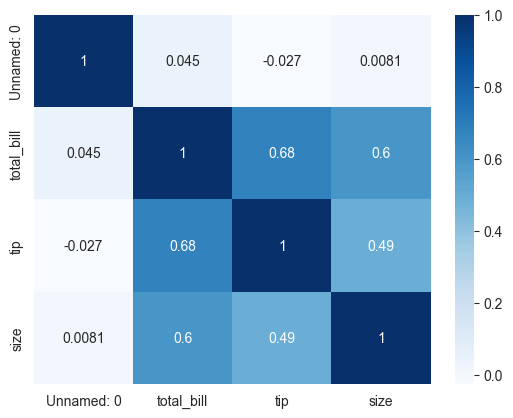

In [33]:
# 1:Heatmaps
sns.heatmap(L_df.corr(numeric_only=True), annot=True , cmap='Blues') #correlation

<Axes: xlabel='time', ylabel='day'>

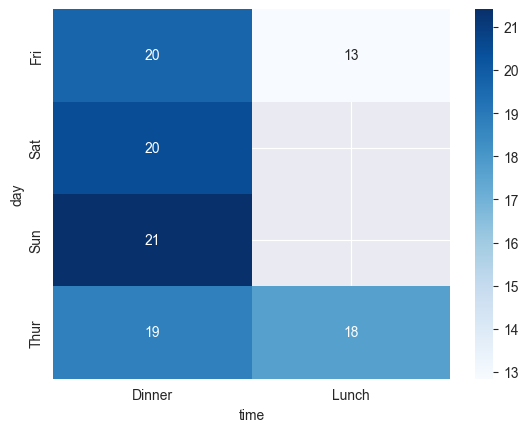

In [37]:
orders_m = L_df.pivot_table(index='day', columns='time', values='total_bill')
sns.heatmap(orders_m, annot=True , cmap='Blues')

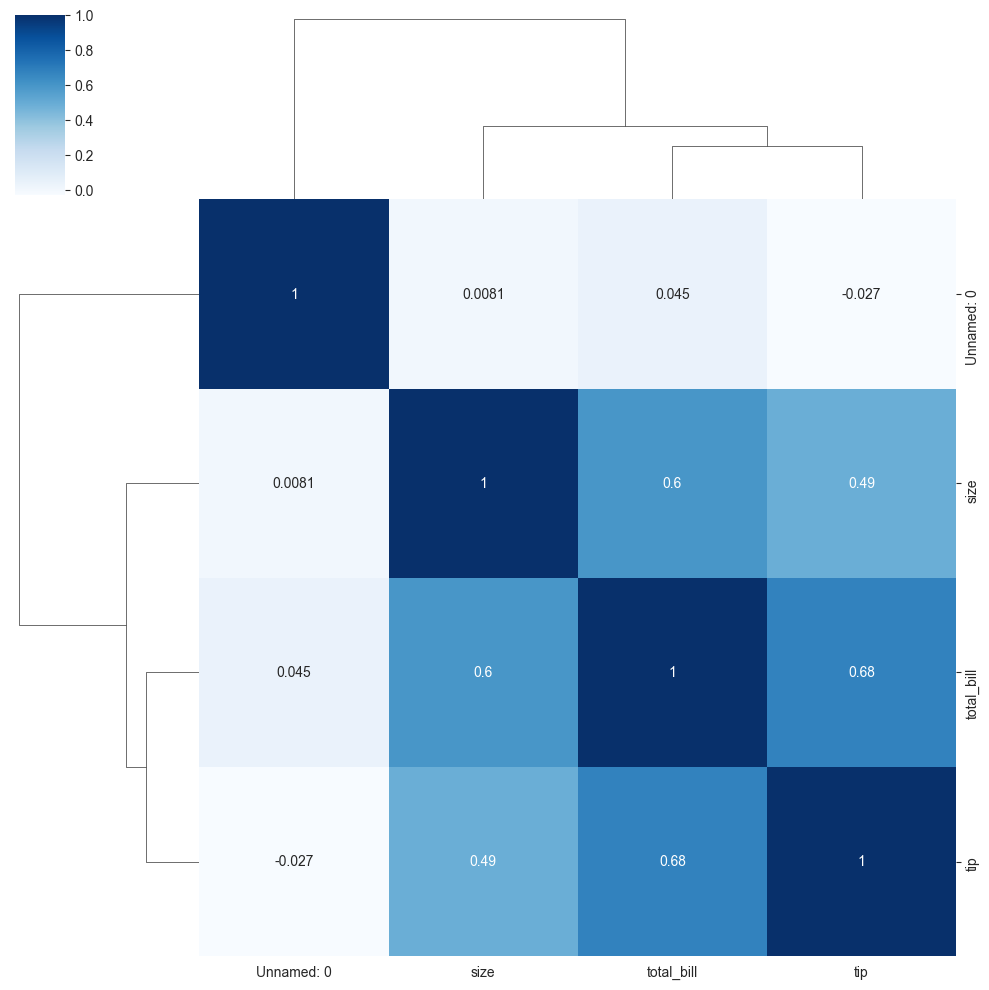

In [38]:
# Cluster Map = heatmap + clustring
sns.clustermap(L_df.corr(numeric_only=True), annot=True , cmap='Blues')

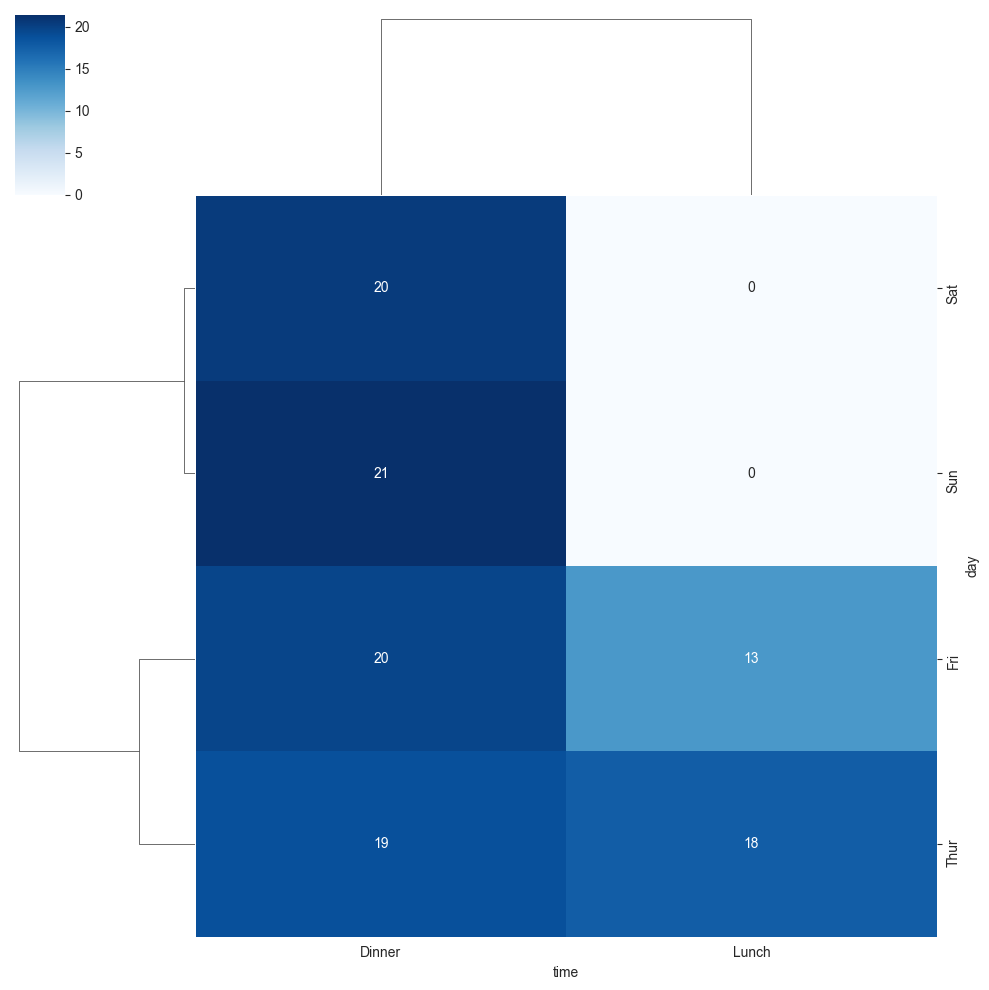

In [40]:
orders_m2 = L_df.pivot_table(index='day', columns='time', values='total_bill' , fill_value=0)
sns.clustermap(orders_m2, annot=True , cmap='Blues')

#### PairGrid  
provides a flexible grid for plotting pairwise relationships between variables  

 Upper triangle  
 Lower triangle  
 Diagonal  

pairgrid vs pairplot?  
Pairplot -> automatic  
pairgrid -> full customization

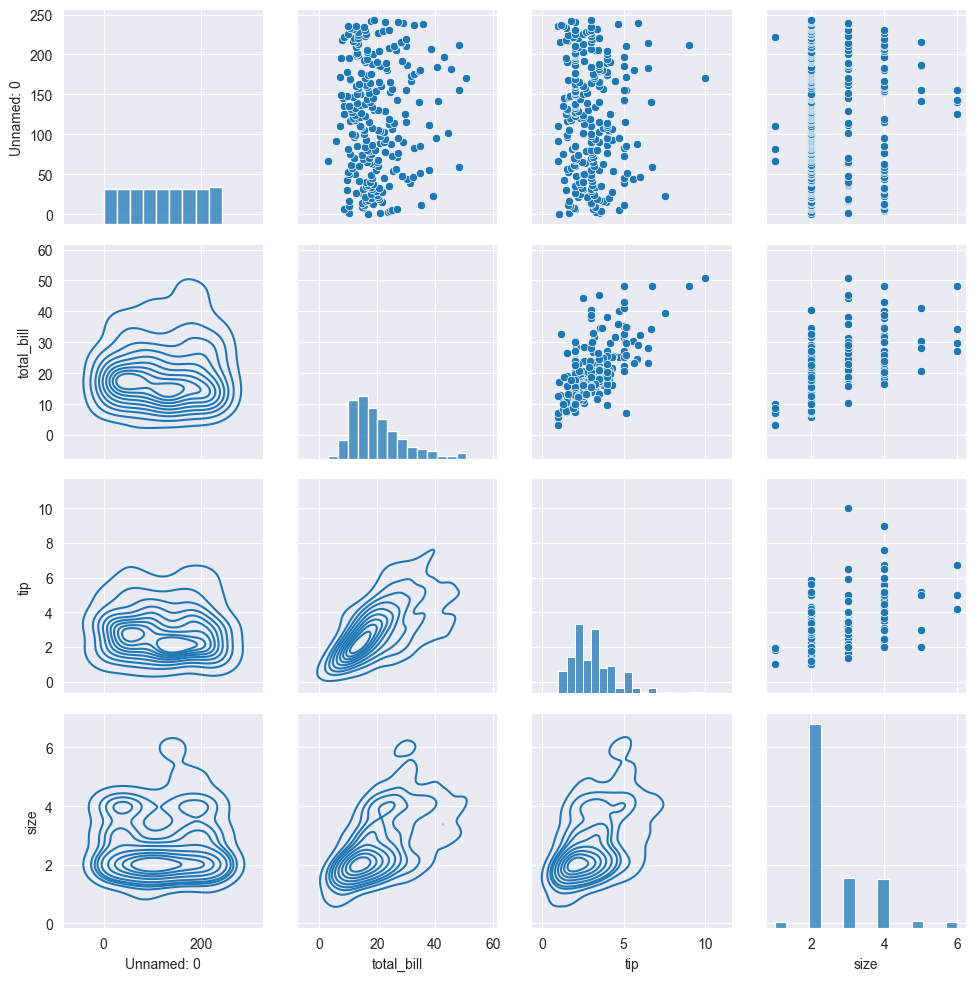

In [ ]:
pg = sns.PairGrid(L_df)


pg.map_upper(sns.scatterplot)
pg.map_diag(sns.histplot)
pg.map_lower(sns.kdeplot)



#### Facet Grid ??  
to create multiple plots by splitting data into subsets based on categorical variables


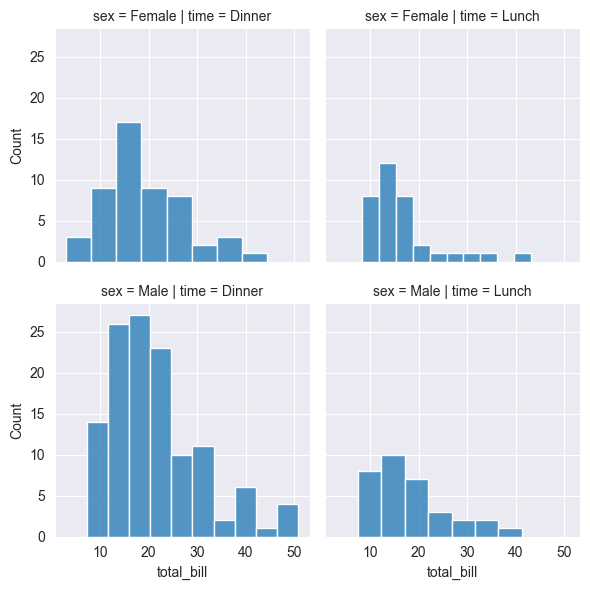

In [45]:
fg = sns.FacetGrid(L_df, row="sex", col="time")
fg.map(sns.histplot, "total_bill")


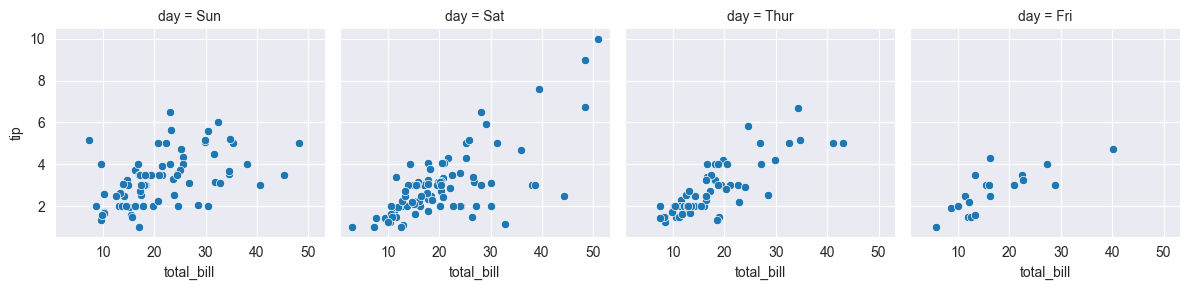

In [46]:
fg2 = sns.FacetGrid(L_df, col="day")
fg2.map(sns.scatterplot, "total_bill", "tip")

#### FacetGrid vs PairGrid ?  
FacetGrid: splits data by categories and repeats the same plot for each group  
PairGrid: shows pairwise relationships between multiple variables using customizable plots  

#### Regression Plots ?  
shows the relationship between two variables along with a fitted regression line to indicate trend direction  
1. regplot?  
scatter + regression line  
2. lmplot?
regression + grouping




<Axes: xlabel='total_bill', ylabel='tip'>

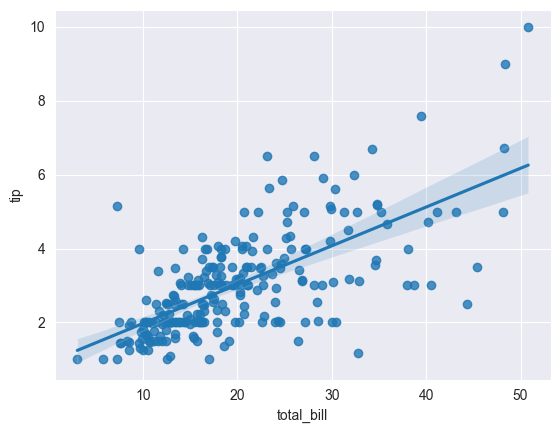

In [48]:
sns.regplot(x='total_bill', y='tip', data=L_df)

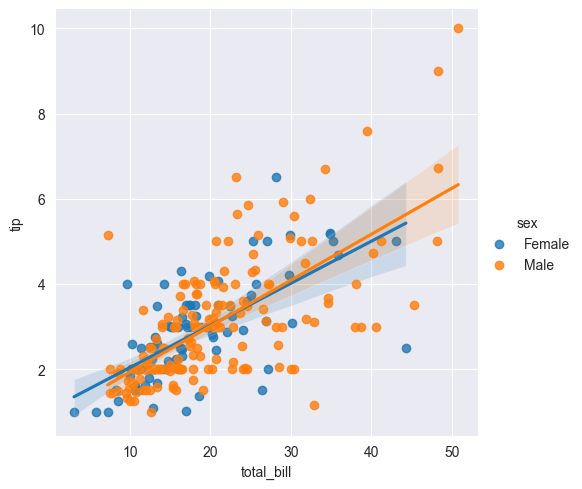

In [52]:
sns.lmplot(x='total_bill', y='tip', data=L_df, hue='sex')

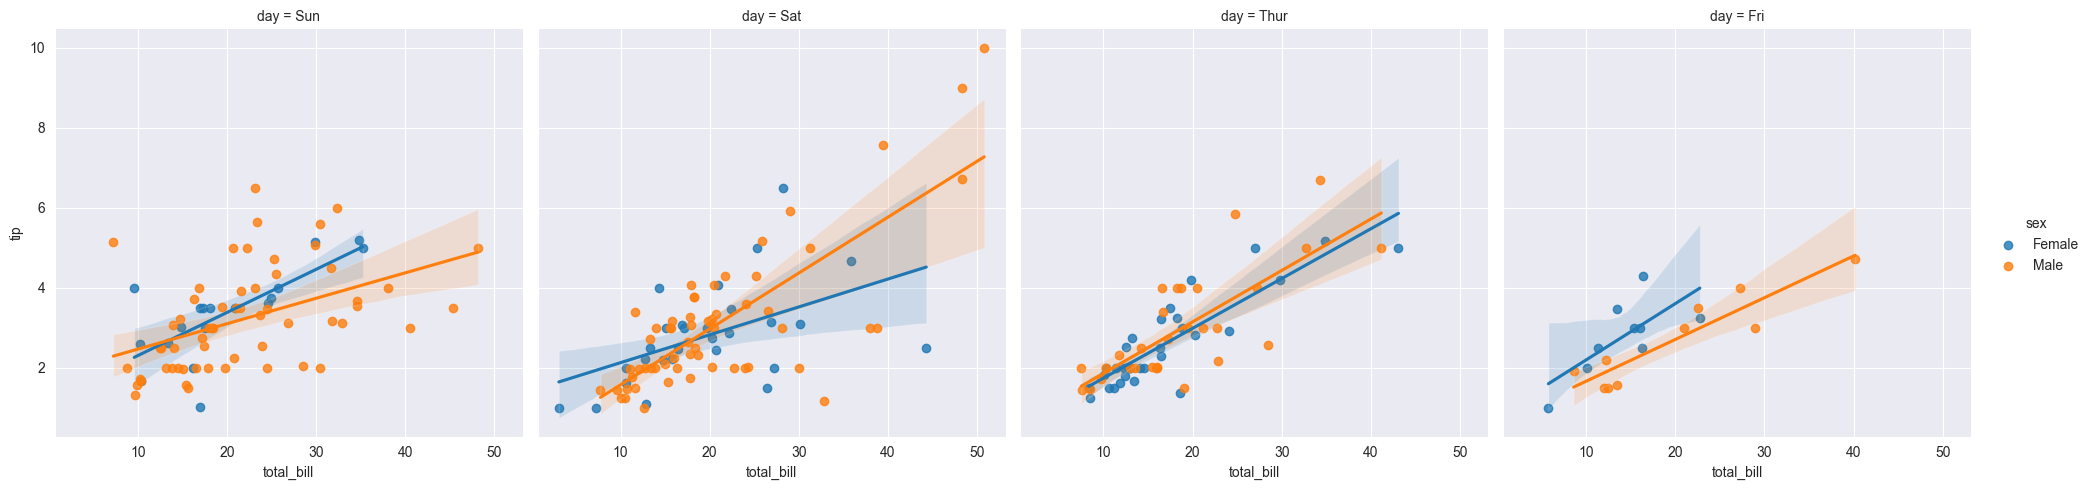

In [53]:
sns.lmplot(x='total_bill', y='tip', data=L_df,col='day',hue='sex')